<a href="https://colab.research.google.com/github/annshita/CT-Scan-based-Kidney-Disease-Diagnosis/blob/main/CLIP%2BCNN_5_fold_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:
dataset_path = "/content/drive/MyDrive/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

import torch
import clip
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-9ly1lx6g
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-9ly1lx6g
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=db32814aa5ff4a872232750194463ba21f88dc3508cc8bffe9eb3e774cd30a5b
  Stored in directory: /tmp/pip-ephem-wheel-cache-9h2lsgip/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 127MiB/s]


In [ ]:
from tqdm.auto import tqdm

In [ ]:
class CTDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.samples = []

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, img), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, label

In [ ]:
dataset_path = "/content/drive/MyDrive/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

dataset = CTDataset(dataset_path, preprocess)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

import torch.nn as nn

class ImprovedCLIPClassifier(nn.Module):
    def __init__(self, clip_model, num_classes):
        super().__init__()
        self.clip = clip_model

        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.clip.encode_image(x)

        return self.classifier(features.float())

In [ ]:
num_classes = len(dataset.classes)

model_improved = ImprovedCLIPClassifier(model, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_improved.classifier.parameters(), lr=5e-4)

In [ ]:
def train(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Current Device ID:", torch.cuda.current_device())

print("Model Device:", next(model_improved.parameters()).device)

CUDA Available: True
Device: cuda
GPU Name: Tesla T4
Current Device ID: 0
Model Device: cuda:0


In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
k_folds = 5
num_epochs = 10   # changed to 10 epochs
batch_size = 32

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
indices = np.arange(len(dataset))

fold_results = []
all_fold_history = []
best_fold_data = None
best_fold_acc = 0.0


# =========================
# TRAIN FUNCTION
# =========================
def train_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    return total_loss / len(loader), correct / total


# =========================
# VALIDATION FUNCTION
# =========================
def eval_epoch(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{100*correct/total:.2f}%"
            )

    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_labels),
        np.array(all_preds)
    )


# =========================
# K-FOLD LOOP
# =========================
for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
    print(f"\n========== Fold {fold+1}/{k_folds} ==========")

    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # fresh model each fold
    model_fold = ImprovedCLIPClassifier(model, num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model_fold.classifier.parameters(),
        lr=5e-4,
        weight_decay=1e-4
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_epoch_acc = 0.0
    all_fold_preds = []
    all_fold_true = []
    all_fold_metrics = []

    for epoch in range(num_epochs):
        print(f"\nFold {fold+1} | Epoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_epoch(
            model_fold, train_loader, criterion, optimizer
        )

        val_loss, val_acc, y_true, y_pred = eval_epoch(
            model_fold, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        # keep best epoch of this fold
        if val_acc > best_epoch_acc:
            best_epoch_acc = val_acc
            best_epoch_true = y_true
            best_epoch_pred = y_pred

        from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score
        import numpy as np

        fold_results.append(best_epoch_acc)
        all_fold_history.append(history)

        # store predictions
        all_fold_preds.append(best_epoch_pred)
        all_fold_true.append(best_epoch_true)

        # compute metrics for this fold
        precision = precision_score(best_epoch_true, best_epoch_pred, average='macro')
        recall = recall_score(best_epoch_true, best_epoch_pred, average='macro')
        accuracy = accuracy_score(best_epoch_true, best_epoch_pred)

        cm = confusion_matrix(best_epoch_true, best_epoch_pred)

        specificity = []
        for i in range(len(cm)):
            tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
            fp = cm[:, i].sum() - cm[i, i]
            specificity.append(tn / (tn + fp))

        specificity = np.mean(specificity)

        all_fold_metrics.append({
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "specificity": specificity
        })


    if best_epoch_acc > best_fold_acc:
        best_fold_acc = best_epoch_acc
        best_fold_data = {
            "history": history,
            "y_true": best_epoch_true,
            "y_pred": best_epoch_pred
        }


# =========================
# FINAL RESULTS
# =========================
print("\n===== 5-Fold Results =====")
for i, score in enumerate(fold_results):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMean Accuracy: {np.mean(fold_results):.4f}")
print(f"Std Accuracy : {np.std(fold_results):.4f}")


# =====================================================
# LATER USE THESE VARIABLES FOR PLOTTING
# =====================================================

train_loss_list = best_fold_data["history"]["train_loss"]
val_loss_list   = best_fold_data["history"]["val_loss"]
train_acc_list  = best_fold_data["history"]["train_acc"]
val_acc_list    = best_fold_data["history"]["val_acc"]

y_true = best_fold_data["y_true"]
y_pred = best_fold_data["y_pred"]


========== Fold 1/5 ==========

Fold 1 | Epoch 1/10


Training:   0%|          | 0/312 [00:00<?, ?it/s]

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss: 0.4138 | Train Acc: 0.8533
Val   Loss: 0.1227 | Val   Acc: 0.9651

Fold 1 | Epoch 2/10


Training:   0%|          | 0/312 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss: 0.0597 | Train Acc: 0.9792
Val   Loss: 0.0172 | Val   Acc: 0.9944

Fold 5 | Epoch 10/10


Training:   0%|          | 0/312 [00:00<?, ?it/s]

Validation:   0%|          | 0/78 [00:00<?, ?it/s]

Train Loss: 0.0393 | Train Acc: 0.9865
Val   Loss: 0.0086 | Val   Acc: 0.9984

===== 5-Fold Results =====
Fold 1: 0.9651
Fold 2: 0.9807
Fold 3: 0.9815
Fold 4: 0.9884
Fold 5: 0.9888
Fold 6: 0.9896
Fold 7: 0.9956
Fold 8: 0.9956
Fold 9: 0.9964
Fold 10: 0.9964
Fold 11: 0.9602
Fold 12: 0.9823
Fold 13: 0.9859
Fold 14: 0.9896
Fold 15: 0.9936
Fold 16: 0.9936
Fold 17: 0.9936
Fold 18: 0.9968
Fold 19: 0.9972
Fold 20: 0.9972
Fold 21: 0.9554
Fold 22: 0.9803
Fold 23: 0.9879
Fold 24: 0.9879
Fold 25: 0.9904
Fold 26: 0.9916
Fold 27: 0.9928
Fold 28: 0.9960
Fold 29: 0.9960
Fold 30: 0.9968
Fold 31: 0.9425
Fold 32: 0.9847
Fold 33: 0.9847
Fold 34: 0.9916
Fold 35: 0.9920
Fold 36: 0.9948
Fold 37: 0.9948
Fold 38: 0.9960
Fold 39: 0.9980
Fold 40: 0.9980
Fold 41: 0.9566
Fold 42: 0.9807
Fold 43: 0.9867
Fold 44: 0.9867
Fold 45: 0.9916
Fold 46: 0.9964
Fold 47: 0.9964
Fold 48: 0.9964
Fold 49: 0.9964
Fold 50: 0.9984

Mean Accuracy: 0.9881
Std Accuracy : 0.0121


In [ ]:
print("Total folds stored:", len(all_fold_metrics))

Total folds stored: 10


In [ ]:
fixed_metrics = all_fold_metrics[9::10]

In [ ]:
print("Total stored entries:", len(all_fold_metrics))

Total stored entries: 10


In [ ]:
entries_per_fold = len(all_fold_metrics) // 5

In [ ]:
fixed_metrics = []

for i in range(5):
    idx = (i + 1) * entries_per_fold - 1   # last index of each fold
    fixed_metrics.append(all_fold_metrics[idx])

In [ ]:
print("\n===== Correct 5-Fold Metrics =====")

for i, m in enumerate(fixed_metrics):
    print(f"\nFold {i+1}:")
    print(f"Accuracy   : {m['accuracy']:.4f}")
    print(f"Precision  : {m['precision']:.4f}")
    print(f"Recall     : {m['recall']:.4f}")
    print(f"Specificity: {m['specificity']:.4f}")


===== Correct 5-Fold Metrics =====

Fold 1:
Accuracy   : 0.9807
Precision  : 0.9814
Recall     : 0.9655
Specificity: 0.9927

Fold 2:
Accuracy   : 0.9867
Precision  : 0.9788
Recall     : 0.9868
Specificity: 0.9959

Fold 3:
Accuracy   : 0.9964
Precision  : 0.9929
Recall     : 0.9955
Specificity: 0.9989

Fold 4:
Accuracy   : 0.9964
Precision  : 0.9929
Recall     : 0.9955
Specificity: 0.9989

Fold 5:
Accuracy   : 0.9984
Precision  : 0.9981
Recall     : 0.9966
Specificity: 0.9994


In [ ]:
fixed_preds = []
fixed_true = []

entries_per_fold = len(all_fold_preds) // 5

for i in range(5):
    idx = (i + 1) * entries_per_fold - 1
    fixed_preds.append(all_fold_preds[idx])
    fixed_true.append(all_fold_true[idx])

all_true = np.concatenate(fixed_true)
all_pred = np.concatenate(fixed_preds)

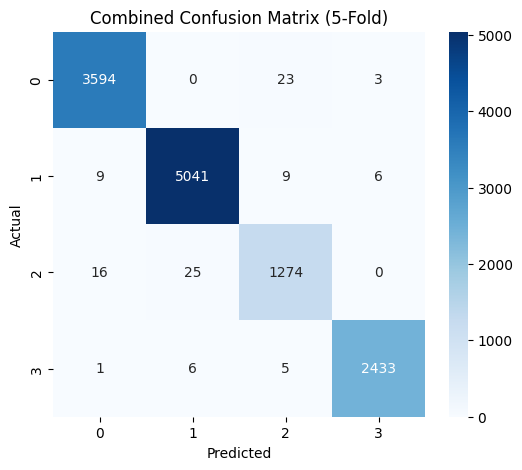

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# combine all folds
all_true = np.concatenate(fixed_true)
all_pred = np.concatenate(fixed_preds)

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Combined Confusion Matrix (5-Fold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import numpy as np

# extract values
accuracies   = [m["accuracy"] for m in fixed_metrics]
precisions   = [m["precision"] for m in fixed_metrics]
recalls      = [m["recall"] for m in fixed_metrics]
specificities= [m["specificity"] for m in fixed_metrics]

print("\n===== Final Average Metrics (5-Fold CV) =====")

print(f"Accuracy    : {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precision   : {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Recall      : {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Specificity : {np.mean(specificities):.4f} ± {np.std(specificities):.4f}")


===== Final Average Metrics (5-Fold CV) =====
Accuracy    : 0.9917 ± 0.0068
Precision   : 0.9888 ± 0.0074
Recall      : 0.9880 ± 0.0118
Specificity : 0.9972 ± 0.0026


In [ ]:
print("\nMetric        Mean ± Std")
print("----------------------------")
print(f"Accuracy     {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precision    {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Recall       {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Specificity  {np.mean(specificities):.4f} ± {np.std(specificities):.4f}")


Metric        Mean ± Std
----------------------------
Accuracy     0.9917 ± 0.0068
Precision    0.9888 ± 0.0074
Recall       0.9880 ± 0.0118
Specificity  0.9972 ± 0.0026


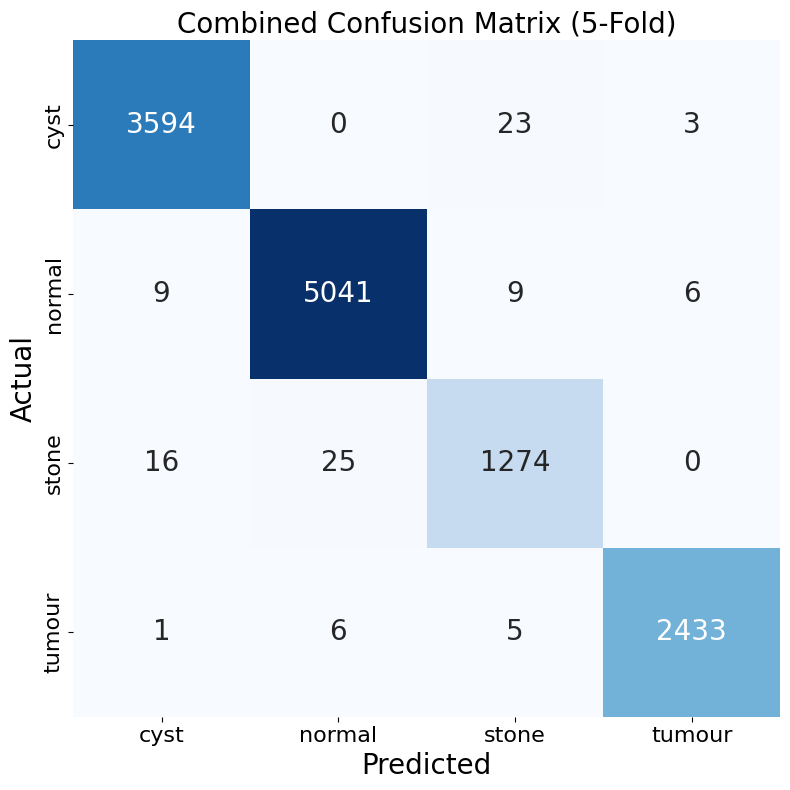

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class names
class_names = ['cyst', 'normal', 'stone', 'tumour']

plt.figure(figsize=(8, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,                    # ❌ remove colorbar
    annot_kws={"size": 20}         # 🔠 numbers inside boxes
)

plt.title("Combined Confusion Matrix (5-Fold)", fontsize=20)
plt.xlabel("Predicted", fontsize=20)
plt.ylabel("Actual", fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()